# EDA Fusionado: Datos Viejos + Datos Nuevos

Este notebook une los dos análisis exploratorios (EDA_Datos_viejos y EDA_Datos_nuevos) en un único flujo, manteniendo íntegras las transformaciones y limpiezas realizadas en cada uno de los notebooks originales.

- **Parte 1**: EDA sobre el dataset antiguo (`alojamientos-turisticos-sample.csv`).
- **Parte 2**: EDA sobre el dataset nuevo (`total.csv` + `inside_Airbnb.csv`).

## Librerías

In [ ]:
# Importamos las librerías necesarias para ambos análisis
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Parte 1: EDA - Datos viejos

In [ ]:
df_viejo = pd.read_csv("alojamientos-turisticos-sample.csv")

In [ ]:
#comprobanción rápida que el dataset esta correctamente cargado. Mostramos las primeras filas del dataset. Nos sirve para visualizar ejemplos reales de los datos. Y detectar posibles datos incongruentes.
df_viejo.head()

,apartment_id,md5,name,description,host_id,neighborhood_overview,neighbourhood_name,neighbourhood_district,latitude,longitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,is_instant_bookable,reviews_per_month,country,city,insert_date
0,36187629,66fff4225feb2ddf104ea38f76e4bff1,Piso reformado excelente ubicacion,Apartamento reformado hace dos meses en el Cab...,261787331,NaN,BETERO,POBLATS MARITIMS,3.947.149,-3.346,...,10.0,10.0,10.0,10.0,NaN,True,0.22,spain,valencia,2019-12-31
1,5388904,48790b4dd865e98cc1f5302a2bba1a50,Nice Room in a Penthouse,The apartment is fully equipped. Large bathroo...,20843074,NaN,la Nova Esquerra de l'Eixample,Eixample,4.138.353,215.388,...,8.0,10.0,10.0,10.0,NaN,False,0.01,spain,barcelona,2021-01-12
2,39982406,d3a60e8898bd8ddce4325c8d3d6af7c8,LUXURY 5 BEDROOM APARTMENT IN MONCLOA-ARAVACA,Luxury Apartment located in a priveleged zone ...,308267305,Very quiet residential area in a Posh area of ...,El Plantío,Moncloa - Aravaca,4.046.614,-380.948,...,NaN,NaN,NaN,NaN,VT-12318,True,NaN,spain,madrid,2020-01-10
3,19344018,e2f33bae8c814924e8ce7e6efa8e7245,Habitación zona Atocha,Pareja joven alquila habitación para semana de...,135531703,NaN,Palos de Moguer,Arganzuela,4.040.507.011.669.010,-3.693.182.634.598.120,...,NaN,NaN,NaN,NaN,NaN,True,NaN,spain,madrid,2019-01-14
4,17218380,11295740bea58c9ae080a459cc8094c5,Spacious villa for rent with private pool,This large holiday home is located in a quiet ...,8345284,L'Escala has a strategic location - everything...,L'Escala,NaN,4.210.782.265.163.360,3.141.601.421.913.330,...,8.0,9.0,8.0,8.0,HUTG-020958,True,0.29,spain,girona,2018-10-20


In [ ]:
# verificamos numero de filas y columnas, tipo de cada columna (int, float...) y valores nulos por columna. Detectamos posibles errores estructurales.
# El dataset se compone de 10.000 registros.
df_viejo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 10000 non-null  int64  
 1   md5                          10000 non-null  object 
 2   name                         9992 non-null   object 
 3   description                  9862 non-null   object 
 4   host_id                      10000 non-null  int64  
 5   neighborhood_overview        5899 non-null   object 
 6   neighbourhood_name           10000 non-null  object 
 7   neighbourhood_district       6079 non-null   object 
 8   latitude                     10000 non-null  object 
 9   longitude                    10000 non-null  object 
 10  room_type                    9999 non-null   object 
 11  accommodates                 10000 non-null  int64  
 12  bathrooms                    9926 non-null   float64
 13  bedrooms         

In [ ]:
df_viejo.describe()

,apartment_id,host_id,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,...,availability_365,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
count,1.000000e+04,1.000000e+04,10000.000000,9926.000000,9930.000000,9955.000000,9746.000000,10000.000000,9999.000000,9999.000000,...,10000.000000,10000.000000,7291.000000,7282.000000,7288.000000,7277.000000,7286.000000,7276.000000,7276.000000,7396.000000
mean,2.115440e+07,9.058066e+07,4.272300,1.595910,1.937059,2.982421,101.211090,4.953000,759.622962,13.011701,...,187.938800,26.020600,91.929776,9.450151,9.315587,9.623883,9.622152,9.544942,9.137713,1.431202
std,1.157967e+07,8.695851e+07,2.582716,0.990137,1.370144,4.779022,86.099548,17.728763,498.423889,11.834651,...,130.777964,52.347588,9.226981,0.946763,1.006235,0.826610,0.827528,0.767761,0.996765,1.588320
min,1.196400e+04,1.070400e+04,1.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.010000
25%,1.328672e+07,1.488728e+07,2.000000,1.000000,1.000000,1.000000,45.000000,1.000000,62.000000,0.000000,...,66.000000,0.000000,89.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,0.270000
50%,2.059847e+07,6.533700e+07,4.000000,1.000000,2.000000,2.000000,75.000000,2.000000,1125.000000,11.000000,...,183.000000,5.000000,94.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,0.840000
75%,2.995999e+07,1.428246e+08,6.000000,2.000000,3.000000,4.000000,124.000000,4.000000,1125.000000,26.000000,...,318.000000,27.000000,98.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.060000
max,4.806155e+07,3.874783e+08,29.000000,13.000000,50.000000,300.000000,500.000000,1125.000000,1125.000000,30.000000,...,365.000000,588.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,12.910000


**FILTRO POR CIUDAD**

Antes de continuar con el resto del análisis, normalizamos el campo de ciudad y filtramos el dataset para quedarnos únicamente con las ciudades objetivo del estudio.

In [ ]:
#normalizamos ciudad
df_viejo["city"] = (df_viejo["city"].astype(str).str.lower().str.strip())
df_viejo["city"].value_counts().head(10)

#filtramos por ciudades objetivo
ciudades_objetivo = ["madrid", "barcelona", "valencia",]

df_viejo = df_viejo[df_viejo["city"].isin(ciudades_objetivo)]
print(df_viejo.shape)
df_viejo["city"].value_counts()


(5551, 40)


,count
city,
barcelona,2823
madrid,2200
valencia,528


In [ ]:

# Eliminación de duplicados
print(f"Registros totales: {len(df_viejo)}")
print(f"apartment_id únicos: {df_viejo['apartment_id'].nunique()}")
print(f"Duplicados por apartment_id: {df_viejo.duplicated(subset=['apartment_id']).sum()}")

Registros totales: 5551
apartment_id únicos: 5363
Duplicados por apartment_id: 188


In [ ]:
# Ejemplo de un inmueble duplicado, para verificar que son realmente el mismo anuncio
ejemplo_id = df_viejo[df_viejo.duplicated(subset=["apartment_id"], keep=False)]["apartment_id"].iloc[0]
df_viejo[df_viejo["apartment_id"] == ejemplo_id][["apartment_id", "name", "city", "price", "insert_date"]]

,apartment_id,name,city,price,insert_date
17,33766241,Spacious n´bright room in Madrid Center,madrid,50.0,2019-11-09
4899,33766241,Spacious n´bright room in Madrid Center,madrid,50.0,2020-01-10


In [ ]:
# Eliminamos los duplicados sobre df_viejo para que
# todos los pasos posteriores del análisis trabajen ya con datos depurados.
n_antes = len(df_viejo)

df_viejo = df_viejo.drop_duplicates()
df_viejo = df_viejo.drop_duplicates(subset=["apartment_id"], keep="first")

print(f"Registros antes de deduplicar: {n_antes}")
print(f"Registros después de deduplicar: {len(df_viejo)}")
print(f"Registros eliminados: {n_antes - len(df_viejo)} ({round((n_antes - len(df_viejo)) / n_antes * 100, 2)}%)")

Registros antes de deduplicar: 5551
Registros después de deduplicar: 5363
Registros eliminados: 188 (3.39%)


In [ ]:
# Distribución por ciudad después de la eliminación de duplicados
df_viejo["city"].value_counts()

,count
city,
barcelona,2718
madrid,2132
valencia,513


**Resultado (dataset original):** de los 5.551 registros de Madrid, Barcelona y Valencia se eliminan **188 duplicados** por `apartment_id`, quedando **5.363 inmuebles únicos** (2.718 en Barcelona, 2.132 en Madrid y 513 en Valencia). No existían duplicados exactos de fila, motivo por el cual la comprobación inicial con `duplicated()` no los detectaba: los registros repetidos diferían en algún campo secundario (por ejemplo `insert_date`), pero se refieren al mismo inmueble.

**ANALISIS DE VALORES NULOS**

In [ ]:
df_viejo.isna().sum().sort_values(ascending=False)


,0
license,3559
neighborhood_overview,1948
review_scores_value,1223
review_scores_location,1222
review_scores_checkin,1221
review_scores_accuracy,1219
review_scores_communication,1217
review_scores_cleanliness,1217
review_scores_rating,1215
last_review_date,1159


Se puede observar que la mayoría de nulos se concentran en los campos de reviews, overviews y licencias. No todos los anuncios tienen reseñas, por lo que este dato tiene sentido.

Sin embargo, que un apartamento no tenga precio o que no ponga el nombre de la ciudad es susceptible a ser borrado.

Después de esta ultima función, analizamos las variables y su tipo segun su grado (criticas, secundarias e informativas)


1. **Criticas**: Precio y localizacion.

2.  **Secundarias:** bedrooms y bathrooms.


In [ ]:
#Eliminacion de nulos en variables críticas
#sin precio no se puede analizar y sin localizacion no podemos comparar por zonas.
df_viejo_2 = df_viejo.dropna(subset=["price", "city"])
print(f"Porcentaje de registros eliminados: {(len(df_viejo_2)-len(df_viejo))/len(df_viejo)*100}%")
print(f"Nº de registros actual: {len(df_viejo_2)}")

Porcentaje de registros eliminados: -1.8459817266455343%
Nº de registros actual: 5264


Analisis del precio

In [ ]:
print(f"Media: {round(df_viejo_2.price.mean(),2)}")
print(f"Mediana: {df_viejo_2.price.median()}")
print(f"Precio maximo: {df_viejo_2.price.max()}")
print(f"Precio minimo: {df_viejo_2.price.min()}")
print(f"Cuartil 25: {df_viejo_2.price.quantile(0.25)}")
print(f"Cuartil 75: {df_viejo_2.price.quantile(0.75)}")

Media: 79.16
Mediana: 60.0
Precio maximo: 500.0
Precio minimo: 6.0
Cuartil 25: 35.0
Cuartil 75: 96.0


- La media es casi 20 euros más alta que la mediana, indicándonos que el precio puede estar ligeramente sesgado a la derecha, debido a valores extremos  

- El precio máximo es de 500 euros la noche, mientras que el precio mínimo es de 6. Esto se tratará más adelante con el tratamiento de valores extremos.

- El 25% de los datos se sitúan por debajo de los 35 euros, mientras que el 75% de los datos se encuentran por debajo de los 96 euros.

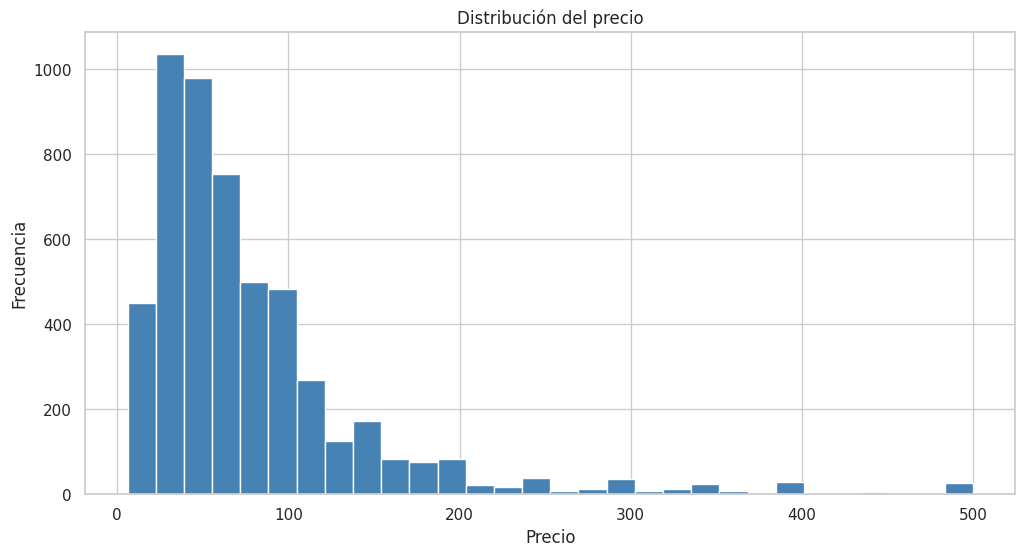

In [ ]:
# Histograma

plt.hist(df_viejo_2["price"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribución del precio")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

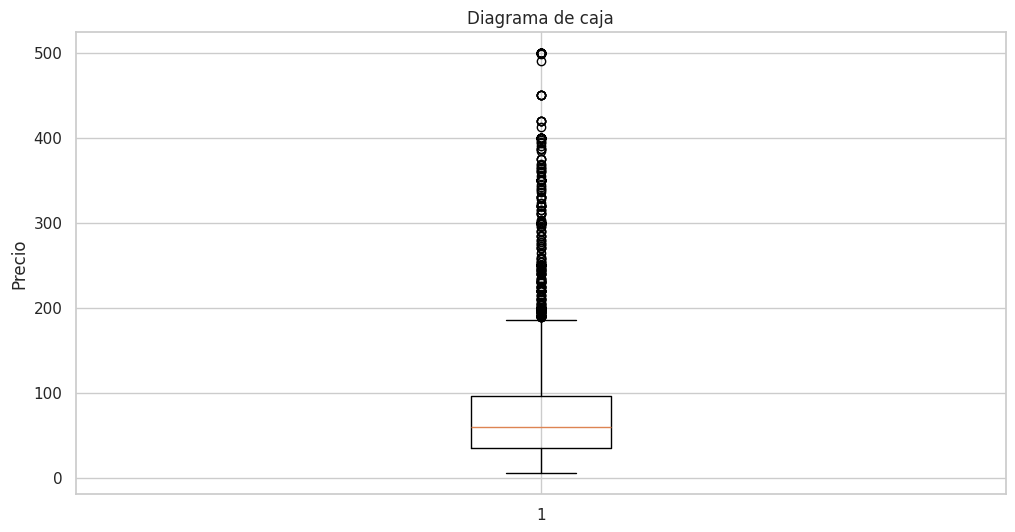

In [ ]:
# Boxplot

plt.boxplot(df_viejo_2["price"])
plt.title("Diagrama de caja")
plt.ylabel("Precio")
plt.show()

In [ ]:
Q1_viejo = df_viejo_2["price"].quantile(0.25)
Q3_viejo = df_viejo_2["price"].quantile(0.75)
IQR_viejo = Q3_viejo - Q1_viejo

limite_inferior_viejo = Q1_viejo - 1.5 * IQR_viejo
limite_superior_viejo = Q3_viejo + 1.5 * IQR_viejo

outliers_viejo = df_viejo_2[(df_viejo_2["price"] < limite_inferior_viejo) | (df_viejo_2["price"] > limite_superior_viejo)]

print(f"Límite inferior: {limite_inferior_viejo}")
print(f"Límite superior: {limite_superior_viejo}")
print(f"Cantidad de outliers: {len(outliers_viejo)}")
print(f"Porcentaje de outliers: {round(len(outliers_viejo)/len(df_viejo_2)*100,2)}%")

Límite inferior: -56.5
Límite superior: 187.5
Cantidad de outliers: 338
Porcentaje de outliers: 6.42%


In [ ]:
df_viejo_2 = df_viejo_2[
(df_viejo_2["price"] >= Q1_viejo - 1.5 * IQR_viejo) &
    (df_viejo_2["price"] <= Q3_viejo + 1.5 * IQR_viejo)
]

In [ ]:
numericas_viejo = df_viejo_2.select_dtypes(include="number")

# Correlación de todas las variables con "price", ordenada de mayor a menor
correlacion_price_viejo = (numericas_viejo.corr()["price"]
                     .drop("price")          # quita la autocorrelación (1.0)
                     .sort_values(ascending=False))

print(correlacion_price_viejo)

accommodates                   0.572321
beds                           0.444964
bedrooms                       0.320417
availability_365               0.145944
bathrooms                      0.116031
availability_90                0.088117
availability_60                0.079511
availability_30                0.072248
review_scores_location         0.067516
review_scores_cleanliness      0.054105
maximum_nights                 0.053099
number_of_reviews              0.019960
review_scores_rating           0.010326
review_scores_accuracy        -0.007010
review_scores_communication   -0.016940
minimum_nights                -0.024645
review_scores_value           -0.032975
reviews_per_month             -0.035693
review_scores_checkin         -0.049729
apartment_id                  -0.083243
host_id                       -0.097552
Name: price, dtype: float64


***Conclusiones del análisis de correlación con el precio***

*(Valores calculados sobre el dataset ya deduplicado y sin outliers de precio.)*

***Variables con mayor impacto positivo***

Las variables más correlacionadas con el precio son **huéspedes (0,57)**, **camas (0,45)** y **dormitorios (0,32)**. Esto tiene mucho sentido: a mayor capacidad y tamaño del alojamiento, mayor precio. Son las variables más útiles para predecir el precio. `bathrooms` (0,12) correlaciona de forma más débil de lo esperado, probablemente por la baja variabilidad de esta columna (la gran mayoría de inmuebles tiene 1 o 2 baños).

***Variables débiles***

`availability_365`, `availability_30`, `availability_60` y `availability_90` tienen correlaciones muy bajas (0,07–0,15). La disponibilidad casi no influye en el precio, lo que sugiere que los anfitriones no ajustan mucho el precio según cuántos días están disponibles.

***Variables negativas y nulas***

Todas las variables de reviews tienen correlación negativa o cercana a 0 con el precio. Esto es interesante: los alojamientos más caros tienden a tener menos reseñas y peores valoraciones relativas. Puede deberse a que los alojamientos de lujo reciben menos reservas y por tanto menos reseñas.

`minimum_nights` y `maximum_nights` prácticamente no tienen relación con el precio. Las restricciones de estancia no lo determinan.

In [ ]:
#dataset limpio hasta ahora (ya viene filtrado por ciudad desde los primeros pasos)
df_clean_viejo = df_viejo.copy()
print(df_clean_viejo.shape)
df_clean_viejo

(5363, 40)


,apartment_id,md5,name,description,host_id,neighborhood_overview,neighbourhood_name,neighbourhood_district,latitude,longitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,is_instant_bookable,reviews_per_month,country,city,insert_date
0,36187629,66fff4225feb2ddf104ea38f76e4bff1,Piso reformado excelente ubicacion,Apartamento reformado hace dos meses en el Cab...,261787331,NaN,BETERO,POBLATS MARITIMS,3.947.149,-3.346,...,10.0,10.0,10.0,10.0,NaN,True,0.22,spain,valencia,2019-12-31
1,5388904,48790b4dd865e98cc1f5302a2bba1a50,Nice Room in a Penthouse,The apartment is fully equipped. Large bathroo...,20843074,NaN,la Nova Esquerra de l'Eixample,Eixample,4.138.353,215.388,...,8.0,10.0,10.0,10.0,NaN,False,0.01,spain,barcelona,2021-01-12
2,39982406,d3a60e8898bd8ddce4325c8d3d6af7c8,LUXURY 5 BEDROOM APARTMENT IN MONCLOA-ARAVACA,Luxury Apartment located in a priveleged zone ...,308267305,Very quiet residential area in a Posh area of ...,El Plantío,Moncloa - Aravaca,4.046.614,-380.948,...,NaN,NaN,NaN,NaN,VT-12318,True,NaN,spain,madrid,2020-01-10
3,19344018,e2f33bae8c814924e8ce7e6efa8e7245,Habitación zona Atocha,Pareja joven alquila habitación para semana de...,135531703,NaN,Palos de Moguer,Arganzuela,4.040.507.011.669.010,-3.693.182.634.598.120,...,NaN,NaN,NaN,NaN,NaN,True,NaN,spain,madrid,2019-01-14
5,30808704,8a04ff34abb53d484d162962a1b4b6f3,Habitación en Madrid! <<Wifi>>Perfecto para 2!!!,Habitación con todo lo que necesitas para tu c...,115839544,"Barrio de Antaño en Madrid, lleno de bares y l...",Vista Alegre,Carabanchel,4.038.349,-374.807,...,10.0,10.0,9.0,9.0,NaN,True,1.53,spain,madrid,2020-10-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9990,11397725,5e72d921ef9a562842b1eeec4ce4ea87,Комната для двоих. metro Alfonso X,"Рядом с моим жильем parc de les Agües, Condis,...",59809817,NaN,Can Baró,Horta-Guinardó,4.141.806.727.741.940,2.162.982.561.392.330,...,NaN,NaN,NaN,NaN,NaN,False,NaN,spain,barcelona,2018-04-12
9991,35555761,e5de2d7b9414944df2adbb9cdc859190,"Apartment with terrace, Views, WiFi and Parking!",Luxe appartement met een prachtig uitzicht op ...,19556457,"Het appartement is erg centraal gelegen, heeft...",PENYA-ROJA,CAMINS AL GRAU,3.945.579,-34.563,...,10.0,10.0,10.0,10.0,NaN,False,2.22,spain,valencia,2019-09-30
9992,22454692,f8c848e9f6ad7890bed8c600cbdfa378,Moderno apartamento a estrenar - WINDROSE 1,"Nuestro piso está bien situado, a 10 minutos d...",88589135,NaN,Lucero,Latina,4.040.732,-374.661,...,10.0,9.0,9.0,9.0,VT-5943,True,3.35,spain,madrid,2020-03-17
9996,25280928,d4710f3312c051861df5bd882645ed47,Modern apartment in Legazpi,"Apartamento muy céntrico, tranquilo y luminoso...",190957904,NaN,Chopera,Arganzuela,4.039.344,-369.582,...,10.0,10.0,9.0,9.0,VT-8435,True,1.51,spain,madrid,2020-10-17


In [ ]:
#Eliminamos registros con nulos relevantes (precio y huéspedes)
df_clean_viejo = df_clean_viejo.dropna(subset=["price", "accommodates"])
print(df_clean_viejo.shape)
df_clean_viejo[["city", "price", "accommodates"]].head()

(5264, 40)


,city,price,accommodates
0,valencia,90.0,4
1,barcelona,100.0,1
2,madrid,220.0,10
3,madrid,200.0,2
5,madrid,31.0,2


In [ ]:
#Eliminamos precios menores a 20€
df_clean_viejo = df_clean_viejo[df_clean_viejo["price"] >= 20]
print(df_clean_viejo.shape)
df_clean_viejo

(5006, 40)


,apartment_id,md5,name,description,host_id,neighborhood_overview,neighbourhood_name,neighbourhood_district,latitude,longitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,is_instant_bookable,reviews_per_month,country,city,insert_date
0,36187629,66fff4225feb2ddf104ea38f76e4bff1,Piso reformado excelente ubicacion,Apartamento reformado hace dos meses en el Cab...,261787331,NaN,BETERO,POBLATS MARITIMS,3.947.149,-3.346,...,10.0,10.0,10.0,10.0,NaN,True,0.22,spain,valencia,2019-12-31
1,5388904,48790b4dd865e98cc1f5302a2bba1a50,Nice Room in a Penthouse,The apartment is fully equipped. Large bathroo...,20843074,NaN,la Nova Esquerra de l'Eixample,Eixample,4.138.353,215.388,...,8.0,10.0,10.0,10.0,NaN,False,0.01,spain,barcelona,2021-01-12
2,39982406,d3a60e8898bd8ddce4325c8d3d6af7c8,LUXURY 5 BEDROOM APARTMENT IN MONCLOA-ARAVACA,Luxury Apartment located in a priveleged zone ...,308267305,Very quiet residential area in a Posh area of ...,El Plantío,Moncloa - Aravaca,4.046.614,-380.948,...,NaN,NaN,NaN,NaN,VT-12318,True,NaN,spain,madrid,2020-01-10
3,19344018,e2f33bae8c814924e8ce7e6efa8e7245,Habitación zona Atocha,Pareja joven alquila habitación para semana de...,135531703,NaN,Palos de Moguer,Arganzuela,4.040.507.011.669.010,-3.693.182.634.598.120,...,NaN,NaN,NaN,NaN,NaN,True,NaN,spain,madrid,2019-01-14
5,30808704,8a04ff34abb53d484d162962a1b4b6f3,Habitación en Madrid! <<Wifi>>Perfecto para 2!!!,Habitación con todo lo que necesitas para tu c...,115839544,"Barrio de Antaño en Madrid, lleno de bares y l...",Vista Alegre,Carabanchel,4.038.349,-374.807,...,10.0,10.0,9.0,9.0,NaN,True,1.53,spain,madrid,2020-10-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9990,11397725,5e72d921ef9a562842b1eeec4ce4ea87,Комната для двоих. metro Alfonso X,"Рядом с моим жильем parc de les Agües, Condis,...",59809817,NaN,Can Baró,Horta-Guinardó,4.141.806.727.741.940,2.162.982.561.392.330,...,NaN,NaN,NaN,NaN,NaN,False,NaN,spain,barcelona,2018-04-12
9991,35555761,e5de2d7b9414944df2adbb9cdc859190,"Apartment with terrace, Views, WiFi and Parking!",Luxe appartement met een prachtig uitzicht op ...,19556457,"Het appartement is erg centraal gelegen, heeft...",PENYA-ROJA,CAMINS AL GRAU,3.945.579,-34.563,...,10.0,10.0,10.0,10.0,NaN,False,2.22,spain,valencia,2019-09-30
9992,22454692,f8c848e9f6ad7890bed8c600cbdfa378,Moderno apartamento a estrenar - WINDROSE 1,"Nuestro piso está bien situado, a 10 minutos d...",88589135,NaN,Lucero,Latina,4.040.732,-374.661,...,10.0,9.0,9.0,9.0,VT-5943,True,3.35,spain,madrid,2020-03-17
9996,25280928,d4710f3312c051861df5bd882645ed47,Modern apartment in Legazpi,"Apartamento muy céntrico, tranquilo y luminoso...",190957904,NaN,Chopera,Arganzuela,4.039.344,-369.582,...,10.0,10.0,9.0,9.0,VT-8435,True,1.51,spain,madrid,2020-10-17


In [ ]:
#verificamos paso anterior
df_clean_viejo["price"].describe()


,price
count,5006.000000
mean,82.441698
std,71.375352
min,20.000000
25%,39.000000
50%,60.000000
75%,99.000000
max,500.000000


OCUPACION EN EL TIEMPO EN TÉRMINOS RELATIVOS

In [ ]:
# Convertimos disponibilidad en ocupación estimada (1 - disponibilidad relativa)
df_clean_viejo["availability_30"]  = 1 - df_clean_viejo["availability_30"] / 30
df_clean_viejo["availability_60"]  = 1 - df_clean_viejo["availability_60"] / 60
df_clean_viejo["availability_90"]  = 1 - df_clean_viejo["availability_90"] / 90
df_clean_viejo["availability_365"] = 1 - df_clean_viejo["availability_365"] / 365

df_clean_viejo[["availability_30", "availability_60", "availability_90", "availability_365"]].describe()

,availability_30,availability_60,availability_90,availability_365
count,5006.000000,5006.000000,5006.000000,5006.000000
mean,0.599321,0.546115,0.506348,0.518875
std,0.382590,0.378917,0.377148,0.370167
min,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.166667,0.133333,0.134247
50%,0.700000,0.566667,0.477778,0.536986
75%,1.000000,0.983333,0.933333,0.882192
max,1.000000,1.000000,1.000000,1.000000


# Parte 2: EDA - Datos nuevos

In [ ]:
df_datos_nuevos = pd.read_csv('total.csv')

#Hacemos un info() para echar un vistazo rápidamente al número de registros, campos y nulos
df_datos_nuevos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5017 entries, 0 to 5016
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ciudad         5017 non-null   object 
 1   distrito       5017 non-null   object 
 2   room_id        5017 non-null   int64  
 3   fecha_entrada  5017 non-null   object 
 4   titulo         5017 non-null   object 
 5   precio         5015 non-null   float64
 6   viajeros       3906 non-null   float64
 7   dormitorios    3690 non-null   float64
 8   camas          4725 non-null   float64
 9   baños          3918 non-null   float64
 10  nota           4550 non-null   float64
 11  reseñas        4550 non-null   float64
 12  url            5017 non-null   object 
dtypes: float64(7), int64(1), object(5)
memory usage: 509.7+ KB


**ELIMINACIÓN DE REGISTROS DUPLICADOS (dataset scrapeado)**

El scraping de Airbnb se ejecutó **distrito por distrito**. El buscador de Airbnb no devuelve únicamente anuncios del distrito consultado, sino también anuncios de zonas colindantes, por lo que un mismo anuncio aparece en los resultados de varias búsquedas. El resultado es que el fichero contiene el mismo `room_id` repetido varias veces.

Es el mismo problema que en el dataset original, pero de una magnitud mucho mayor, así que hay que cuantificarlo antes de seguir.

In [ ]:
# Duplicados exactos de fila
print(f"Duplicados exactos de fila: {df_datos_nuevos.duplicated().sum()}")

# Duplicados de entidad: el mismo anuncio de Airbnb (room_id)
print(f"Registros totales: {len(df_datos_nuevos)}")
print(f"room_id únicos: {df_datos_nuevos['room_id'].nunique()}")
print(f"Duplicados por room_id: {df_datos_nuevos.duplicated(subset=['room_id']).sum()}")

Duplicados exactos de fila: 0
Registros totales: 5017
room_id únicos: 1808
Duplicados por room_id: 3209


In [ ]:
# Comprobamos el origen del duplicado: un mismo anuncio recogido en varios distritos
ejemplo = df_datos_nuevos[df_datos_nuevos.duplicated(subset=["room_id"], keep=False)]["room_id"].iloc[0]
df_datos_nuevos[df_datos_nuevos["room_id"] == ejemplo][["ciudad", "distrito", "room_id", "precio", "titulo"]]

,ciudad,distrito,room_id,precio,titulo
0,Barcelona,Les-Corts,13571420,120.0,Apartamento en Barcelona
302,Barcelona,Poblenou,13571420,120.0,Apartamento en Barcelona
556,Barcelona,Sants-montjuic,13571420,120.0,Apartamento en Barcelona
833,Barcelona,Gracia,13571420,120.0,Apartamento en Barcelona
1111,Barcelona,Eixample,13571420,120.0,Apartamento en Barcelona
1387,Barcelona,Horta~Guinardó,13571420,120.0,Apartamento en Barcelona


In [ ]:
# ¿Un mismo room_id cruza de ciudad? (afectaría al reparto de oferta por ciudad)
print("room_id presentes en más de una ciudad:",
      (df_datos_nuevos.groupby("room_id")["ciudad"].nunique() > 1).sum())

# ¿En cuántos distritos aparece de media cada anuncio?
distritos_por_anuncio = df_datos_nuevos.groupby("room_id")["distrito"].nunique()
print("room_id presentes en más de un distrito:", (distritos_por_anuncio > 1).sum())
print("Media de distritos por anuncio:", round(distritos_por_anuncio.mean(), 2))

room_id presentes en más de una ciudad: 0
room_id presentes en más de un distrito: 1063
Media de distritos por anuncio: 2.77


Ningún anuncio cruza de ciudad, por lo que la asignación de **ciudad** es fiable. En cambio, cada anuncio aparece de media en **2,77 distritos** distintos, así que la asignación de **distrito** es ambigua para los anuncios repetidos.

**Criterio adoptado:** se conserva la primera aparición de cada room_id (keep="first"), que corresponde al primer distrito en el que fue recogido durante el scraping. Esto se documenta como limitación del análisis por distrito, ya que introduce cierto ruido en esa dimensión concreta. Las demás variables (precio, capacidad, tipología, ciudad) no se ven afectadas, ya que son idénticas en todas las repeticiones del mismo anuncio.

In [ ]:
n_antes = len(df_datos_nuevos)

df_datos_nuevos = df_datos_nuevos.drop_duplicates()
df_datos_nuevos = df_datos_nuevos.drop_duplicates(subset=["room_id"], keep="first")

print(f"Registros antes de deduplicar: {n_antes}")
print(f"Registros después de deduplicar: {len(df_datos_nuevos)}")
print(f"Registros eliminados: {n_antes - len(df_datos_nuevos)} ({round((n_antes - len(df_datos_nuevos)) / n_antes * 100, 2)}%)")

Registros antes de deduplicar: 5017
Registros después de deduplicar: 1808
Registros eliminados: 3209 (63.96%)


**Resultado de la eliminación de duplicados (dataset Airbnb):** de los 5.017 registros scrapeados se eliminan **3.209 duplicados**, quedando **1.808 anuncios únicos** (805 en Madrid, 588 en Barcelona y 415 en Valencia).

Este es el hallazgo más relevante de la fase de limpieza: **el 64% del fichero scrapeado eran repeticiones**. Sin esta depuración, el volumen de oferta captado por el scraping estaría sobreestimado en más de 2,7 veces, y las medias y correlaciones estarían sesgadas hacia los anuncios que el buscador devuelve con más frecuencia (típicamente los mejor posicionados, que no son una muestra aleatoria del mercado).

Importamos el CSV con datos adicionales de Inside AirBnb

In [ ]:
# Importamos el archivo y vemos los campos mas relevantes para hacer MERGE
df_inside_Airbnb = pd.read_csv("inside_Airbnb.csv")
df_inside_Airbnb.info()

/tmp/ipykernel_4805/1323829193.py:2: DtypeWarning: Columns (7,12,33,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df_inside_Airbnb = pd.read_csv("inside_Airbnb.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51021 entries, 0 to 51020
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            51021 non-null  int64  
 1   listing_url                                   51021 non-null  object 
 2   scrape_id                                     51021 non-null  int64  
 3   last_scraped                                  51021 non-null  object 
 4   source                                        51021 non-null  object 
 5   name                                          51021 non-null  object 
 6   description                                   49348 non-null  object 
 7   neighborhood_overview                         13863 non-null  object 
 8   picture_url                                   51020 non-null  object 
 9   host_id                                       51021 non-null 

In [ ]:
# Procedemos a realizar el cruce entre tablas, filtrando por las columnas que nos interesan para el analisis

cols_Inside_Airbnb = [
"id",
"hosts_time_as_host_years",
"host_response_time",
"host_response_rate",
"host_acceptance_rate",
"host_is_superhost",
"host_has_profile_pic",
"host_identity_verified",
"property_type",
"room_type",
"minimum_nights",
"maximum_nights",
"license",
"availability_30",
"availability_60",
"availability_90",
"availability_365"
]

# IMPORTANTE: antes de cruzar, comprobamos que la clave de la tabla derecha es única.
# Si "id" estuviese duplicado, el merge multiplicaría filas y reintroduciría duplicados
# en el dataset ya depurado.
print(f"Duplicados por id en Inside Airbnb: {df_inside_Airbnb.duplicated(subset=['id']).sum()}")
df_inside_Airbnb_dedup = df_inside_Airbnb[cols_Inside_Airbnb].drop_duplicates(subset=["id"], keep="first")

filas_antes = len(df_datos_nuevos)
df = pd.merge(df_datos_nuevos, df_inside_Airbnb_dedup, left_on='room_id', right_on='id', how='left')

# Control post-merge: el nº de filas no debe haber cambiado
print(f"Filas antes del merge: {filas_antes}")
print(f"Filas después del merge: {len(df)}")
assert len(df) == filas_antes, "El merge ha multiplicado filas: revisar la unicidad de la clave"

enriquecidos = df['id'].notna().sum()
print(f"\nRegistros enriquecidos: {enriquecidos} de {len(df)} ({round(enriquecidos / len(df) * 100, 1)}%)")
df.info()

Duplicados por id en Inside Airbnb: 0
Filas antes del merge: 1808
Filas después del merge: 1808

Registros enriquecidos: 1192 de 1808 (65.9%)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1808 entries, 0 to 1807
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ciudad                    1808 non-null   object 
 1   distrito                  1808 non-null   object 
 2   room_id                   1808 non-null   int64  
 3   fecha_entrada             1808 non-null   object 
 4   titulo                    1808 non-null   object 
 5   precio                    1807 non-null   float64
 6   viajeros                  1386 non-null   float64
 7   dormitorios               1322 non-null   float64
 8   camas                     1698 non-null   float64
 9   baños                     1393 non-null   float64
 10  nota                      1621 non-null   float64
 11  reseñas                   1621 

Con el merge hemos podido extraer información adicional de **1.192 IDs de los 1.808 anuncios únicos**, enriqueciendo el **65,9%** de los registros del dataset.

El control `assert` posterior al merge es deliberado: un `left join` contra una tabla con clave duplicada es una de las formas más habituales de reintroducir duplicados en un dataset que ya se había limpiado.

In [ ]:
# Echamos un vistazo al tipo de datos que contiene el dataset
df.head()

,ciudad,distrito,room_id,fecha_entrada,titulo,precio,viajeros,dormitorios,camas,baños,...,host_identity_verified,property_type,room_type,minimum_nights,maximum_nights,license,availability_30,availability_60,availability_90,availability_365
0,Barcelona,Les-Corts,13571420,2026-06-01,Apartamento en Barcelona,120.0,4.0,1.0,1.0,1.0,...,t,Entire rental unit,Entire home/apt,1.0,1125.0,Spain - National registration number<br />ESHF...,27.0,52.0,74.0,149.0
1,Barcelona,Les-Corts,1414473753453618431,2026-06-01,Habitación de hotel compartida en Barcelona,96.0,NaN,NaN,4.0,NaN,...,t,Shared room in hotel,Shared room,1.0,6.0,Barcelona - Regional registration number<br />...,29.0,59.0,89.0,364.0
2,Barcelona,Les-Corts,5256656,2026-06-01,Apartamento en Barcelona,190.0,6.0,2.0,3.0,1.0,...,t,Entire rental unit,Entire home/apt,1.0,1125.0,Spain - National registration number<br />ESHF...,18.0,41.0,59.0,130.0
3,Barcelona,Les-Corts,1135216684465108261,2026-06-01,Apartamento en Barcelona,317.0,5.0,2.0,4.0,2.0,...,t,Entire rental unit,Entire home/apt,2.0,365.0,Spain - National registration number<br />ESFC...,7.0,33.0,51.0,326.0
4,Barcelona,Les-Corts,1681696951293486968,2026-06-01,Alojamiento en Barcelona,119.0,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Renombramos las columnas con nombres más claros (antes de aplicar las transformaciones sobre los campos)

In [ ]:
df.rename(columns={
    'room_id': 'id_habitacion',
    'id': 'id_datos_viejos',
    'hosts_time_as_host_years': 'años_como_anfitrion',
    'host_response_time': 'tiempo_respuesta_anfitrion',
    'host_response_rate': 'tasa_respuesta_anfitrion',
    'host_acceptance_rate': 'tasa_aceptacion_anfitrion',
    'host_is_superhost': 'es_superanfitrion',
    'host_has_profile_pic': 'tiene_foto_perfil',
    'host_identity_verified': 'identidad_verificada',
    'property_type': 'tipo_propiedad',
    'room_type': 'tipo_habitacion',
    'minimum_nights': 'noches_minimas',
    'maximum_nights': 'noches_maximas',
    'license': 'licencia',
    'availability_30': 'disponibilidad_30',
    'availability_60': 'disponibilidad_60',
    'availability_90': 'disponibilidad_90',
    'availability_365': 'disponibilidad_365'
}, inplace=True)

Convertimos las columnas al tipo de dato adecuado

In [ ]:
# Convertimos los porcentajes a float

df['tasa_respuesta_anfitrion'] = df['tasa_respuesta_anfitrion'].str.replace('%', '').astype(float)/100
df['tasa_aceptacion_anfitrion'] = df['tasa_aceptacion_anfitrion'].str.replace('%', '').astype(float)/100

# Convertimos los campos con fechas a formato fecha
df['fecha_entrada'] = pd.to_datetime(df['fecha_entrada'])

In [ ]:
# verificamos que los campos se han cambiado correctamente
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1808 entries, 0 to 1807
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ciudad                      1808 non-null   object        
 1   distrito                    1808 non-null   object        
 2   id_habitacion               1808 non-null   int64         
 3   fecha_entrada               1808 non-null   datetime64[ns]
 4   titulo                      1808 non-null   object        
 5   precio                      1807 non-null   float64       
 6   viajeros                    1386 non-null   float64       
 7   dormitorios                 1322 non-null   float64       
 8   camas                       1698 non-null   float64       
 9   baños                       1393 non-null   float64       
 10  nota                        1621 non-null   float64       
 11  reseñas                     1621 non-null   float64     

Convertimos los campos categóricos en datos cuantitativos para poder estudiar la correlación

In [ ]:
# 1 Tiempo_respuesta_anfitrion
orden_respuesta = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1
}
df['tiempo_respuesta_anfitrion'] = df['tiempo_respuesta_anfitrion'].map(orden_respuesta).fillna(0).astype(int)

# 2. licencia → binaria (tiene licencia o no)
df['license_bin'] = df['licencia'].notna().astype(int)

# 3. Convertimos los campos booleanos en int
cols_bool = ['es_superanfitrion', 'tiene_foto_perfil', 'identidad_verificada']
for col in cols_bool:
    df[col] = df[col].map({'t': 1, 'f': 0})




Los campos de disponibilidad los convertimos en porcentajes para poder compararlos más facilmente

In [ ]:
df['disponibilidad_30']  = df['disponibilidad_30']/30
df['disponibilidad_60']  = df['disponibilidad_60']/60
df['disponibilidad_90']  = df['disponibilidad_90']/90
df['disponibilidad_365'] = df['disponibilidad_365']/365

Eliminamos los 2 registros sin precio

In [ ]:
df_clean = df.dropna(subset=['precio'])
df_clean.info()



<class 'pandas.core.frame.DataFrame'>
Index: 1807 entries, 0 to 1807
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ciudad                      1807 non-null   object        
 1   distrito                    1807 non-null   object        
 2   id_habitacion               1807 non-null   int64         
 3   fecha_entrada               1807 non-null   datetime64[ns]
 4   titulo                      1807 non-null   object        
 5   precio                      1807 non-null   float64       
 6   viajeros                    1385 non-null   float64       
 7   dormitorios                 1321 non-null   float64       
 8   camas                       1697 non-null   float64       
 9   baños                       1392 non-null   float64       
 10  nota                        1620 non-null   float64       
 11  reseñas                     1620 non-null   float64       
 1

In [ ]:
print(f"Nº de registros eliminados: {len(df) - len(df_clean)}")
print(f"Porcentaje de registros eliminados: {round((len(df_clean)-len(df))/len(df)*100,4)} %")

Nº de registros eliminados: 1
Porcentaje de registros eliminados: -0.0553 %


Dejamos los registros con los campos de nota y reseña nulas, puesto que supondría la eliminación de casi el 10% de la muestra. Por otro lado, es normal que algunos anuncios, especialmente los más recientes, no cuenten todavía con reseñas

In [ ]:
df_clean.describe()

,id_habitacion,fecha_entrada,precio,viajeros,dormitorios,camas,baños,nota,reseñas,id_datos_viejos,...,es_superanfitrion,tiene_foto_perfil,identidad_verificada,noches_minimas,noches_maximas,disponibilidad_30,disponibilidad_60,disponibilidad_90,disponibilidad_365,license_bin
count,1.807000e+03,1807,1807.000000,1385.000000,1321.000000,1697.000000,1392.000000,1620.000000,1620.000000,1.191000e+03,...,1164.000000,1166.000000,1166.000000,1191.000000,1191.000000,1191.000000,1191.000000,1191.000000,1191.000000,1807.000000
mean,1.002144e+18,2026-06-01 00:00:00,153.069729,3.501805,1.448145,2.077195,1.159483,4.680969,126.082716,8.298521e+17,...,0.362543,0.969983,0.964837,1.906801,502.602015,0.437643,0.564386,0.634313,0.609873,0.422800
min,8.085730e+05,2026-06-01 00:00:00,22.000000,1.000000,1.000000,1.000000,0.000000,3.000000,3.000000,8.423890e+05,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.027302e+17,2026-06-01 00:00:00,91.000000,2.000000,1.000000,1.000000,1.000000,4.570000,23.000000,5.216252e+07,...,0.000000,1.000000,1.000000,1.000000,365.000000,0.200000,0.366667,0.488889,0.300000,0.000000
50%,1.192919e+18,2026-06-01 00:00:00,142.000000,4.000000,1.000000,2.000000,1.000000,4.720000,61.000000,1.029479e+18,...,0.000000,1.000000,1.000000,1.000000,365.000000,0.400000,0.600000,0.677778,0.679452,0.000000
75%,1.461547e+18,2026-06-01 00:00:00,194.000000,4.000000,2.000000,2.000000,1.000000,4.840000,147.000000,1.299193e+18,...,1.000000,1.000000,1.000000,1.000000,1125.000000,0.633333,0.766667,0.822222,0.901370,1.000000
max,1.693541e+18,2026-06-01 00:00:00,699.000000,12.000000,18.000000,20.000000,8.000000,5.000000,2670.000000,1.573205e+18,...,1.000000,1.000000,1.000000,600.000000,1125.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,5.853274e+17,NaN,86.471842,1.736268,0.900630,1.859589,0.692257,0.229645,194.596386,5.557861e+17,...,0.480941,0.170708,0.184271,17.445730,394.637544,0.279312,0.260986,0.240374,0.315021,0.494141


Distribucion de los precios (histograma)

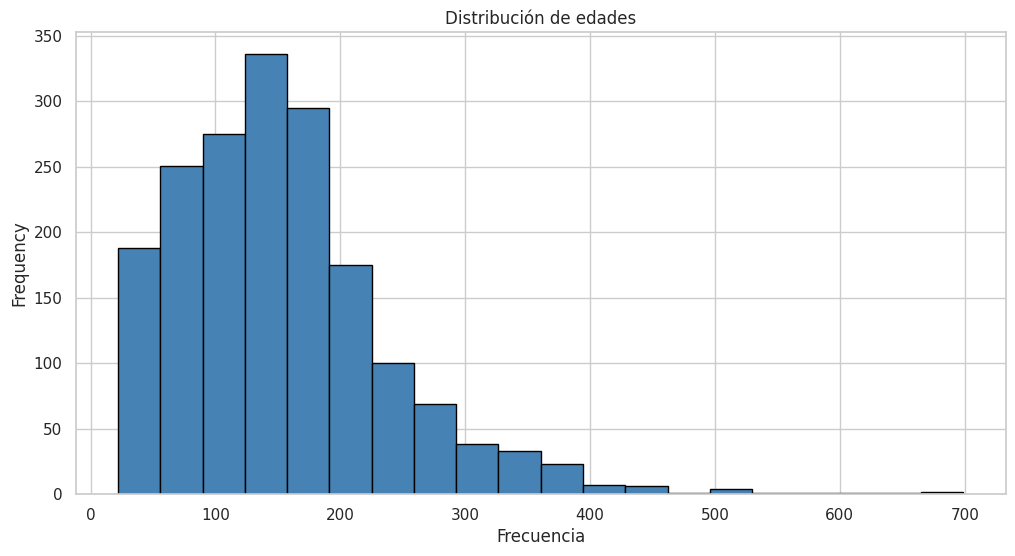

In [ ]:
df_clean["precio"].plot(kind="hist", bins=20, color="steelblue", edgecolor="black")
plt.xlabel("Frecuencia")
plt.title("Distribución de edades")
plt.show()

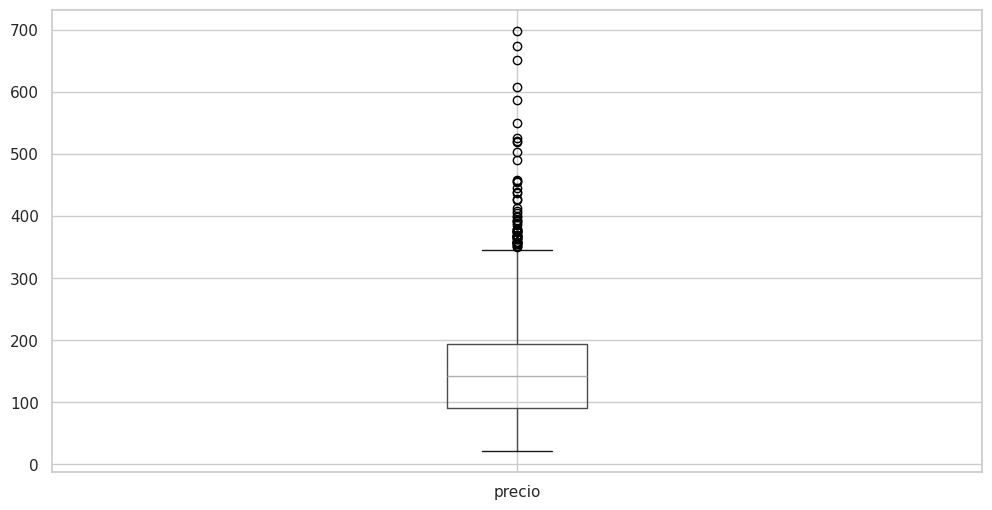

In [ ]:
df_clean.boxplot(column="precio")
plt.show()

In [ ]:
Q1 = df_clean["precio"].quantile(0.25)
Q3 = df_clean["precio"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar outliers
outliers = df_clean[(df_clean["precio"] < limite_inferior) | (df_clean["precio"] > limite_superior)]
print(f"Nº de outliers: {len(outliers)}")

Nº de outliers: 59


In [ ]:
df_clean2 = df_clean[
(df_clean["precio"] >= Q1 - 1.5 * IQR) &
    (df_clean["precio"] <= Q3 + 1.5 * IQR)
]

In [ ]:
print(f"Nº de registros eliminados: {len(df_clean) - len(df_clean2)}")
print(f"Porcentaje de registros eliminados: {round((len(df_clean2)-len(df_clean))/len(df_clean)*100,4)} %")

Nº de registros eliminados: 59
Porcentaje de registros eliminados: -3.2651 %


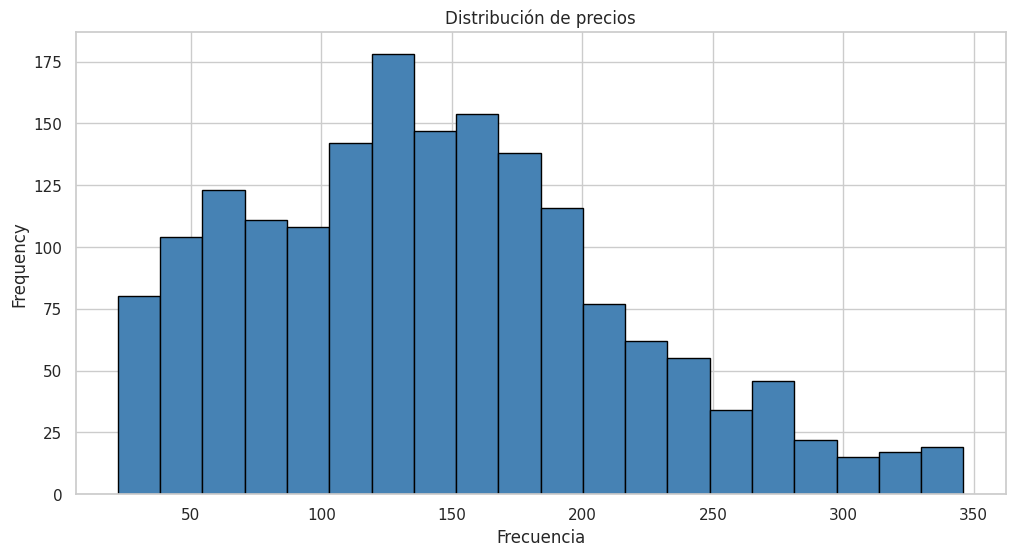

In [ ]:
df_clean2["precio"].plot(kind="hist", bins=20, color="steelblue", edgecolor="black")
plt.xlabel("Frecuencia")
plt.title("Distribución de precios")
plt.show()

In [ ]:
df_clean2.describe()

,id_habitacion,fecha_entrada,precio,viajeros,dormitorios,camas,baños,nota,reseñas,id_datos_viejos,...,es_superanfitrion,tiene_foto_perfil,identidad_verificada,noches_minimas,noches_maximas,disponibilidad_30,disponibilidad_60,disponibilidad_90,disponibilidad_365,license_bin
count,1.748000e+03,1748,1748.000000,1328.000000,1265.000000,1640.000000,1335.000000,1562.000000,1562.000000,1.143000e+03,...,1116.000000,1118.000000,1118.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1748.000000
mean,1.016139e+18,2026-06-01 00:00:00.000000256,144.036613,3.407380,1.396838,2.007927,1.138577,4.677727,123.058259,8.460776e+17,...,0.350358,0.968694,0.963327,1.909011,500.793526,0.435550,0.563313,0.634130,0.607606,0.410755
min,8.085730e+05,2026-06-01 00:00:00,22.000000,1.000000,1.000000,1.000000,0.000000,3.000000,3.000000,8.423890e+05,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.326545e+17,2026-06-01 00:00:00,89.000000,2.000000,1.000000,1.000000,1.000000,4.560000,23.000000,5.317631e+07,...,0.000000,1.000000,1.000000,1.000000,365.000000,0.200000,0.366667,0.488889,0.295890,0.000000
50%,1.203840e+18,2026-06-01 00:00:00,139.000000,3.000000,1.000000,1.000000,1.000000,4.720000,59.000000,1.045442e+18,...,0.000000,1.000000,1.000000,1.000000,365.000000,0.400000,0.600000,0.677778,0.676712,0.000000
75%,1.463773e+18,2026-06-01 00:00:00,188.000000,4.000000,2.000000,2.000000,1.000000,4.840000,142.750000,1.302548e+18,...,1.000000,1.000000,1.000000,1.000000,1125.000000,0.633333,0.766667,0.822222,0.898630,1.000000
max,1.693541e+18,2026-06-01 00:00:00,346.000000,12.000000,18.000000,20.000000,8.000000,5.000000,2670.000000,1.573205e+18,...,1.000000,1.000000,1.000000,600.000000,1125.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,5.776900e+17,NaN,70.616549,1.637128,0.842309,1.816287,0.682488,0.231363,191.995719,5.493541e+17,...,0.477296,0.174221,0.188041,17.804015,393.078869,0.279971,0.261371,0.240201,0.315381,0.492112


La eliminación de los outliers no cambia de forma drástica la media de la muestra:

- Media con outliers: 153,07 €
- Media sin outliers: 144,04 €
(−5,9%)

No obstante, sí lo hace de forma notable con la desviación estándar:

- Desviación típica con outliers: 86,47 €
- Desviación típica sin outliers: 70,62 €
(−18,3%)

*(Cifras recalculadas sobre el dataset deduplicado: 1.807 registros con precio, de los que se eliminan 59 outliers, quedando 1.748.)*

**Correlación entre variables cuantitativas**

In [ ]:
# Variables cuantitativas disponibles
cols_cuantitativas = [
    'precio',
    'viajeros',
    'dormitorios',
    'camas',
    'baños',
    'nota',
    'reseñas',
    'años_como_anfitrion',
    'tasa_respuesta_anfitrion',
    'tasa_aceptacion_anfitrion',
    'es_superanfitrion',
    'tiene_foto_perfil',
    'identidad_verificada',
    'noches_minimas',
    'noches_maximas',
    'disponibilidad_30',
    'disponibilidad_60',
    'disponibilidad_90',
    'disponibilidad_365',
    'tiempo_respuesta_anfitrion',
    'license_bin'
]

# Calculamos la correlación sobre df_clean2 (deduplicado, sin nulos de precio y sin outliers),
# no sobre df, para que sea coherente con el resto del análisis.
correlacion = df_clean2[cols_cuantitativas].corr()['precio'].drop('precio').sort_values(ascending=False)
print(correlacion)

viajeros                      0.542067
dormitorios                   0.403604
años_como_anfitrion           0.353325
license_bin                   0.349573
camas                         0.209006
tiempo_respuesta_anfitrion    0.184796
nota                          0.158633
tasa_aceptacion_anfitrion     0.143842
es_superanfitrion             0.098092
reseñas                       0.083645
noches_maximas                0.063670
disponibilidad_365            0.052848
tiene_foto_perfil             0.052274
identidad_verificada          0.047862
tasa_respuesta_anfitrion      0.030885
noches_minimas                0.001444
baños                        -0.038433
disponibilidad_30            -0.065609
disponibilidad_90            -0.072072
disponibilidad_60            -0.074630
Name: precio, dtype: float64


**Gráfico de correlaciones**

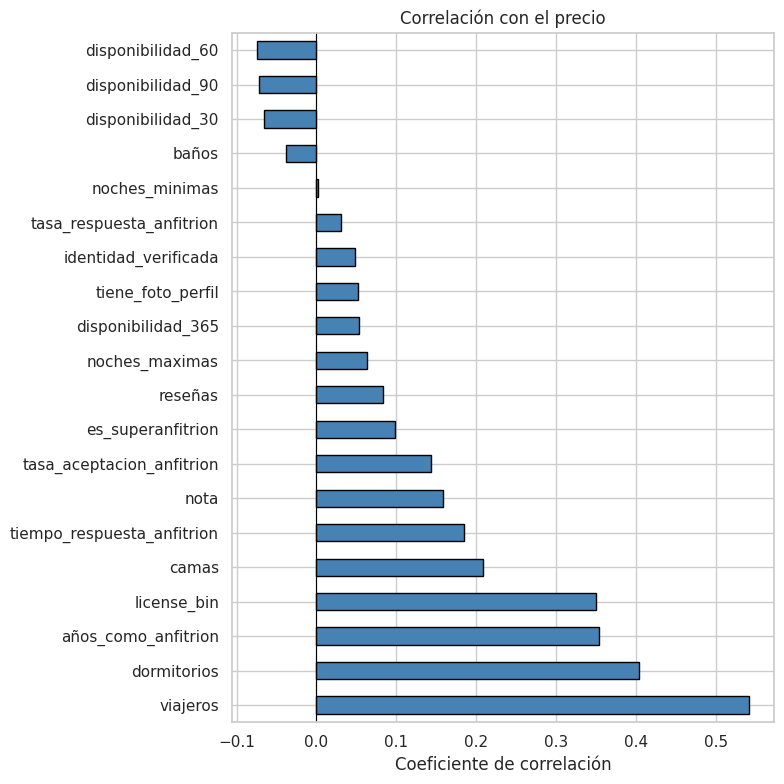

In [ ]:
correlacion.plot(kind='barh', figsize=(8, 8), color='steelblue', edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación con el precio')
plt.xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.show()

El análisis de correlación lineal revela cuáles son los factores del dataset que ejercen mayor influencia, tanto positiva como negativa, sobre las tarifas de los alojamientos *(valores sobre el dataset deduplicado y sin outliers)*:

1.   **Predictores con fuerte correlación positiva:** las variables estructurales y de capacidad del inmueble resultan ser los determinantes más críticos para fijar el precio. La variable `viajeros` lidera el gráfico con una correlación de **0,54**, seguida por `dormitorios` (**0,40**) y `camas` (**0,21**). Esto confirma que a mayor tamaño y capacidad de huéspedes del alojamiento, el precio escala de forma sustancial.

2.   **El factor legal y la experiencia:** un hallazgo de alto interés para el negocio es el impacto de `license_bin` (**0,35**), que sugiere que los inmuebles con licencia turística declarada tienden a registrar precios notablemente superiores, lo que podría estar asociado a una oferta más profesionalizada o regulada. Asimismo, la experiencia del anfitrión (`años_como_anfitrion`, **0,35**) aporta un valor positivo al precio final. Tras la deduplicación estas dos variables ganan peso relativo y se sitúan por delante de `camas`.

3.   **Variables de servicio y reputación:** el comportamiento del anfitrión (`tiempo_respuesta_anfitrion`, **0,19**) y la satisfacción del usuario (`nota`, **0,16**) muestran una correlación positiva moderada, demostrando que la calidad percibida del servicio también permite justificar tarifas más altas.

4.   **Correlación negativa (disponibilidad a corto plazo):** las variables `disponibilidad_30`, `disponibilidad_60` y `disponibilidad_90` muestran coeficientes ligeramente negativos (entre −0,07 y −0,08). Desde la perspectiva del mercado, esto es coherente: los alojamientos que se encuentran constantemente disponibles o vacíos en el corto plazo suelen verse obligados a bajar los precios para atraer demanda, mientras que aquellos con alta ocupación (baja disponibilidad) disfrutan de una prima por escasez.

**Comparativa de precios**

/tmp/ipykernel_4805/2296154158.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='ciudad', y='precio', palette='Set2', showfliers=False)


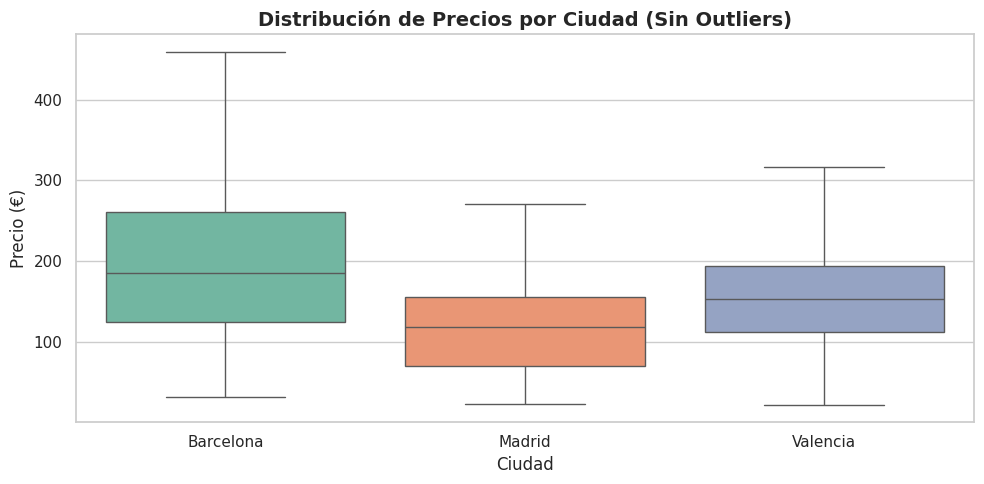

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Visualización de Precios por Ciudad

plt.figure(figsize=(10, 5))
# Usamos un boxplot limitando el eje para evitar que los outliers rompan la visualización
sns.boxplot(data=df_clean, x='ciudad', y='precio', palette='Set2', showfliers=False)
plt.title('Distribución de Precios por Ciudad (Sin Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Precio (€)', fontsize=12)
plt.tight_layout()
plt.show()


Al observar el diagrama de cajas, se hace evidente que Barcelona se posiciona como el mercado más caro y con mayor variabilidad, registrando una mediana que ronda los 180 € y un rango de precios que llega a superar los 400 € por noche incluso tras filtrar los outliers. En contraste, Madrid presenta el mercado más económico y compacto, con una mediana cercana a los 100 € y una dispersión mucho menor. Valencia se sitúa en un término medio, mostrando un comportamiento bastante homogéneo pero con una mediana ligeramente superior a la de Madrid (alrededor de los 140 €).

/tmp/ipykernel_4805/2841866676.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='distrito', y='precio', estimator='median', errorbar=None, order=orden_distritos, palette='viridis')


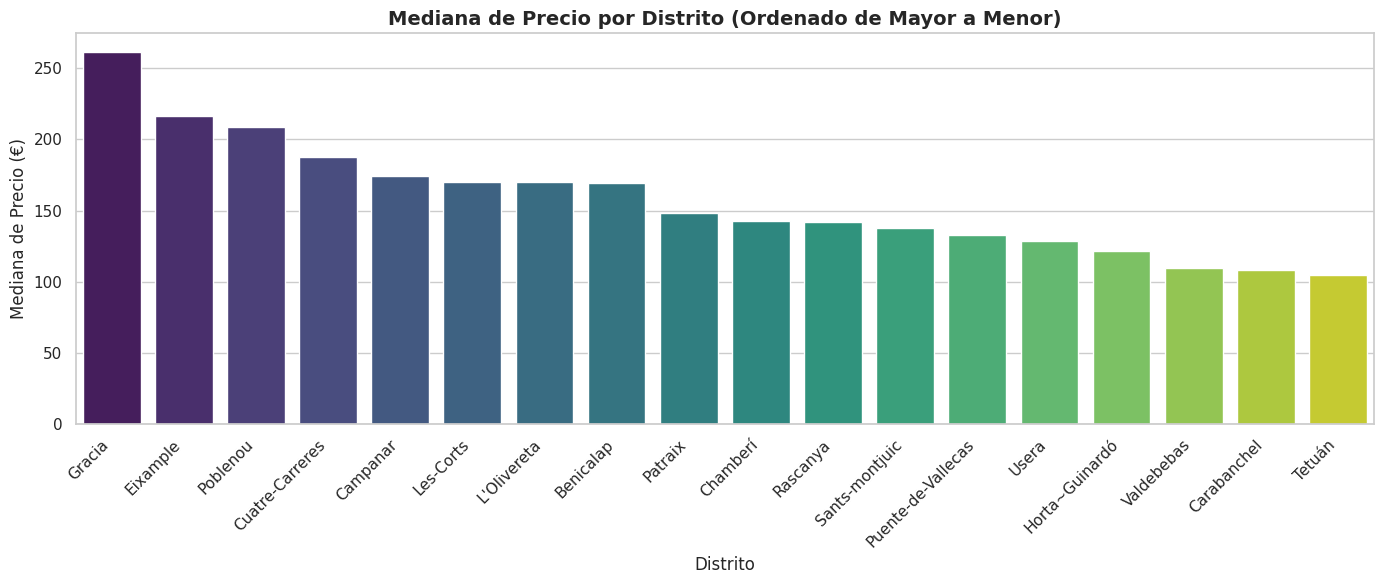

In [ ]:
# 2. Visualización de Precios por Distrito

plt.figure(figsize=(14, 6))

# Agrupamos por distrito y calculamos la mediana para ordenarlos de mayor a menor
orden_distritos = df_clean.groupby('distrito')['precio'].median().sort_values(ascending=False).index

sns.barplot(data=df_clean, x='distrito', y='precio', estimator='median', errorbar=None, order=orden_distritos, palette='viridis')
plt.title('Mediana de Precio por Distrito (Ordenado de Mayor a Menor)', fontsize=14, fontweight='bold')
plt.xlabel('Distrito', fontsize=12)
plt.ylabel('Mediana de Precio (€)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



El gráfico de barras refleja el fuerte impacto de la localización en la tarifa del alojamiento. Los distritos de Barcelona como Eixample, Gracia y Poblenou lideran el top histórico, rozando medianas de casi 200 € por noche. A medida que nos desplazamos hacia la derecha del gráfico, se observa una transición hacia distritos de Valencia (como Campanar o Rascanya, estables en torno a los 140 €) hasta llegar a los distritos periféricos o tradicionalmente más residenciales de Madrid (como Usera o Carabanchel), que cierran la tabla con las tarifas más accesibles, por debajo de los 100 €.

/tmp/ipykernel_4805/373438453.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='tipo_habitacion', y='precio', palette='Pastel1', showfliers=False)


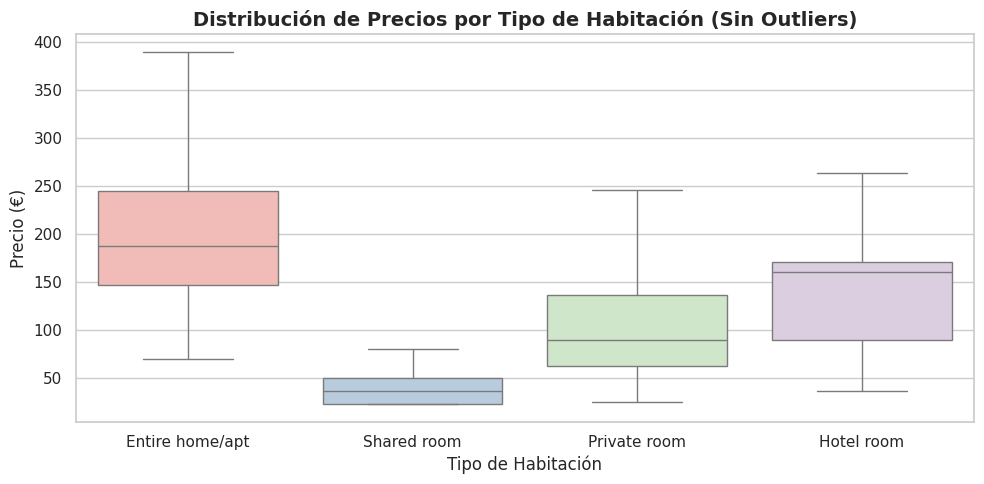

In [ ]:
# 3. Visualización de Precios por Tipo de Habitación

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='tipo_habitacion', y='precio', palette='Pastel1', showfliers=False)
plt.title('Distribución de Precios por Tipo de Habitación (Sin Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Precio (€)', fontsize=12)
plt.tight_layout()
plt.show()



Existe una jerarquía económica muy marcada según la privacidad que ofrece el inmueble. Los alojamientos de tipo "Entire home/apt" (propiedades enteras) no solo registran la mediana más alta (cerca de los 180 €), sino también la mayor dispersión, atrayendo al público dispuesto a pagar tarifas premium. Por otro lado, las habitaciones de hotel ("Hotel room") muestran una mediana competitiva pero un rango intercuartílico más comprimido. Las habitaciones privadas ("Private room") caen por debajo de los 100 € de mediana, mientras que las compartidas ("Shared room") quedan relegadas a un nicho de bajo coste con precios muy estables e inferiores a los 50 €.

/tmp/ipykernel_4805/2855788272.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_prop, x='precio', y='tipo_propiedad', estimator='median', errorbar=None, order=orden_propiedades, palette='coolwarm')


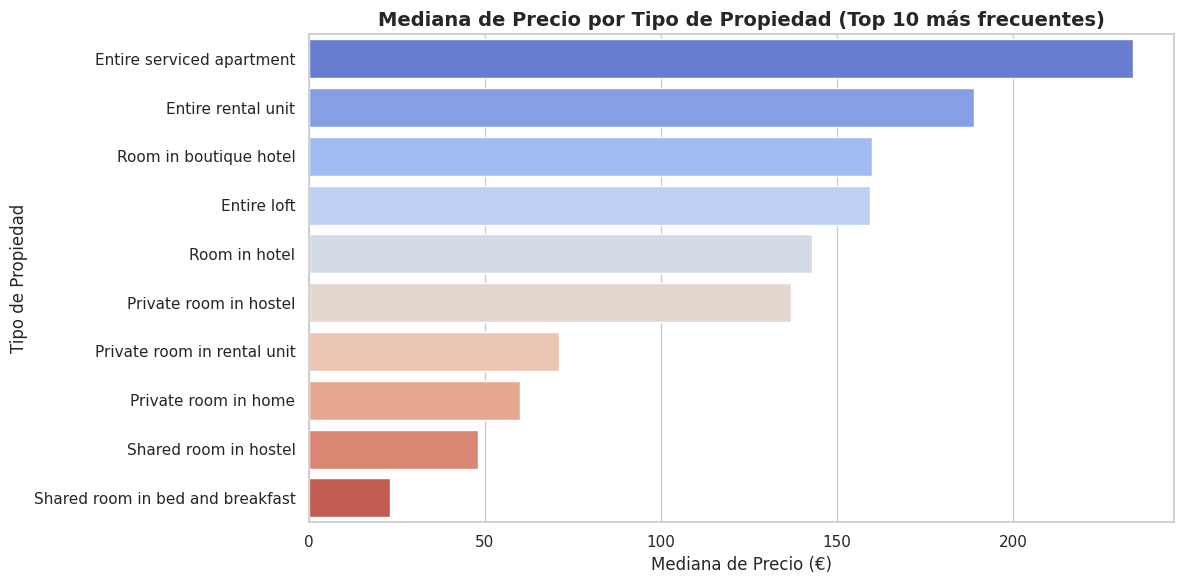

In [ ]:
# 4. Visualización de Precios por Tipo de Propiedad (Top 10 más comunes)

plt.figure(figsize=(12, 6))

# Como hay muchos tipos de propiedad, filtramos por los 10 más frecuentes para no saturar el gráfico
top_propiedades = df_clean['tipo_propiedad'].value_counts().head(10).index
df_top_prop = df_clean[df_clean['tipo_propiedad'].isin(top_propiedades)]


# Ordenamos por la mediana de precio
orden_propiedades = df_top_prop.groupby('tipo_propiedad')['precio'].median().sort_values(ascending=False).index

sns.barplot(data=df_top_prop, x='precio', y='tipo_propiedad', estimator='median', errorbar=None, order=orden_propiedades, palette='coolwarm')
plt.title('Mediana de Precio por Tipo de Propiedad (Top 10 más frecuentes)', fontsize=14, fontweight='bold')
plt.xlabel('Mediana de Precio (€)', fontsize=12)
plt.ylabel('Tipo de Propiedad', fontsize=12)
plt.tight_layout()
plt.show()

El gráfico horizontal detalla cómo el formato comercial influye drásticamente en el precio. Las tipologías enfocadas en ofrecer la propiedad completa y con servicios añadidos, como "Entire serviced apartment", "Entire rental unit" y "Entire condo", se consolidan en la cúspide, superando los 160 € de mediana (llegando el apartamento de servicios a más de 220 €). Los formatos de habitación en hoteles o establecimientos boutique ocupan la zona media (alrededor de 150 €). Finalmente, los alojamientos basados en espacios compartidos o habitaciones en casas particulares (como "Private room in home" o "Shared room in hostel") cierran la lista con medianas inferiores a los 75 €, confirmando que el mercado premia la independencia del huésped.

## 1. ¿Cuántos inmuebles únicos hay en el dataset original frente a los obtenidos de Airbnb?

**Resultado:** el dataset original contiene 10.000 registros en bruto; tras quedarnos solo con Madrid, Barcelona y Valencia (las ciudades de interés del caso) quedan 5.551 registros que, una vez eliminados los 188 duplicados por `apartment_id`, corresponden a **5.363 inmuebles únicos** (2.718 en Barcelona, 2.132 en Madrid y 513 en Valencia).

El dataset obtenido de Airbnb contiene 5.017 registros scrapeados, pero solo **1.808 anuncios únicos** (805 en Madrid, 588 en Barcelona y 415 en Valencia): el 64% de las filas eran el mismo anuncio recogido en búsquedas de distritos colindantes.

| Fuente | Registros en bruto | Inmuebles únicos | % duplicados |
|---|---|---|---|
| Dataset original (3 ciudades) | 5.551 | **5.363** | 3,4% |
| Scraping Airbnb | 5.017 | **1.808** | 64,0% |

## 2. ¿Cuál es la diferencia en número de inmuebles publicados entre las dos fuentes de datos?

**Resultado:** la fuente original publica **3.555 inmuebles más** que la fuente de Airbnb (5.363 frente a 1.808), es decir, casi **el triple de oferta** (296%).

Esta conclusión cambia radicalmente respecto a lo que sugieren los datos en bruto. Comparando registros sin depurar la diferencia parecía de apenas un 10%, lo que llevaría a pensar que ambas fuentes tienen una cobertura de mercado equivalente. Una vez deduplicado, queda claro que **el scraping captura solo una fracción del mercado**: recoge los anuncios que el buscador de Airbnb devuelve en las primeras posiciones para cada distrito, no el censo completo de la oferta.

Implicación para el proyecto: el dataset scrapeado es válido para analizar *relaciones entre variables* (qué explica el precio, cómo se comportan las tipologías), pero **no debe usarse para dimensionar el tamaño del mercado** ni para estimar cuota de oferta por distrito.

## 3. ¿Qué parámetros explican mejor el precio de un inmueble?

**Resultado:** en ambas fuentes, los parámetros que mejor explican el precio son las variables **estructurales / de capacidad** del inmueble *(correlaciones recalculadas sobre los datasets deduplicados)*:

**Dataset original:** huéspedes (0,57), camas (0,45), dormitorios (0,32) y baños (0,12).

**Dataset Airbnb:** viajeros (0,54), dormitorios (0,40), antigüedad del anfitrión (0,35), tener licencia turística (0,35) y camas (0,21).

Es decir, **el tamaño y la capacidad del alojamiento son, con diferencia, los mejores predictores del precio** en ambas fuentes. El dataset Airbnb añade además un factor "legal/confianza" (licencia turística, antigüedad del anfitrión) que el dataset original no permite estudiar por no disponer de esas columnas.

Conviene señalar que la deduplicación reordena ligeramente el ranking del dataset Airbnb: con los datos en bruto, `camas` aparecía por delante de `años_como_anfitrion`, mientras que sobre datos únicos las variables de confianza del anfitrión ganan peso relativo. Es un ejemplo de cómo los registros repetidos distorsionan las correlaciones al sobreponderar determinados perfiles de anuncio.

## 4. ¿Son iguales los factores determinantes en ambas fuentes de datos?

**Resultado:** no son exactamente iguales, pero **comparten el mismo núcleo estructural**. Las variables de capacidad (viajeros/huéspedes, dormitorios y camas) aparecen como las más correlacionadas con el precio en ambas fuentes y con magnitudes similares (0,54–0,57 para la capacidad de huéspedes en las dos), lo cual es una señal de coherencia entre ambos datasets.

La diferencia relevante es que el dataset Airbnb incorpora variables adicionales que en el dataset original no existen (licencia turística, antigüedad y tiempo de respuesta del anfitrión, valoraciones) y que también resultan explicativas del precio.

Por tanto: **los factores "de producto" (tamaño/capacidad) coinciden**, pero el dataset Airbnb permite detectar además factores "de confianza y reputación" que el dataset original no puede capturar. Una diferencia menor es el comportamiento de la variable "baños", que en el dataset original correlaciona débilmente en positivo (0,12) y en el de Airbnb lo hace de forma prácticamente nula (−0,04), atribuible a la baja variabilidad de esa columna en ambas fuentes.

## 5. ¿Se ha encontrado algún inmueble presente en ambas fuentes? ¿Su valoración coincide?

In [ ]:
# Inmuebles presentes en ambas fuentes simultáneamente
# (ambos datasets están ya deduplicados, por lo que el cruce es 1 a 1)
comunes = pd.merge(
    df_clean2[["id_habitacion", "precio", "nota"]],
    df_clean_viejo[["apartment_id", "price", "review_scores_rating"]],
    left_on="id_habitacion", right_on="apartment_id", how="inner"
)

print(f"Inmuebles presentes en ambas fuentes: {len(comunes)}")
print()
print(comunes)
print()
if len(comunes) > 0:
    print(f"Precio medio en Airbnb (dato nuevo): {round(comunes['precio'].mean(), 2)} €")
    print(f"Precio medio en dataset original:    {round(comunes['price'].mean(), 2)} €")

Inmuebles presentes en ambas fuentes: 11

    id_habitacion  precio  nota  apartment_id  price  review_scores_rating
0        13571420   120.0  4.66      13571420  107.0                  92.0
1         6399512   150.0  4.70       6399512  107.0                  95.0
2        19429639   186.0  4.39      19429639   55.0                  88.0
3         1198074   300.0  4.89       1198074  200.0                  95.0
4        18819488   280.0  4.91      18819488  200.0                  97.0
5        18819497   343.0  4.90      18819497  150.0                  98.0
6        17672694   278.0  4.53      17672694   80.0                  92.0
7        10663752   319.0  4.81      10663752   98.0                  96.0
8         4028518   292.0  4.95       4028518   95.0                  99.0
9        22985103    81.0  4.74      22985103   30.0                  94.0
10       23225408   155.0  4.57      23225408   41.0                  92.0

Precio medio en Airbnb (dato nuevo): 227.64 €
Precio medi

**Resultado:** el cruce entre ambas fuentes ya depuradas devuelve **11 inmuebles presentes en las dos**, un solape mínimo (0,6% del dataset de Airbnb). Ambos datasets están deduplicados, por lo que el cruce es 1 a 1 y cada coincidencia es real; sobre los datos en bruto este mismo cruce habría devuelto varias filas por inmueble y habría exagerado el solape.

**Los precios no coinciden en absoluto:** entre los 11 inmuebles comunes, el precio medio es de **227,64 € en el scraping** frente a **105,73 € en el dataset original**, es decir, más del doble. La diferencia es sistemática (ocurre en los 11 casos, no en unos pocos) y se explica por la distancia temporal entre ambas capturas: el dataset original recoge tarifas de 2019 y el scraping, fechas de entrada de 2026.

**Las valoraciones sí son coherentes** una vez normalizada la escala: el dataset original puntúa sobre 100 y el scraping sobre 5. Convertidas a una misma base, los inmuebles con mejor nota en una fuente la mantienen en la otra (por ejemplo, 99/100 frente a 4,95/5), lo que confirma que se trata efectivamente de los mismos alojamientos y no de una coincidencia de identificadores.

Conclusión para el proyecto: **las dos fuentes son complementarias, no redundantes**. El solape es tan pequeño que no procede fusionarlas para ampliar volumen, pero sí permite usar el dataset original como referencia histórica y el scraping como foto del mercado actual.

## 6. ¿En qué fuente hay mayor volatilidad de precios? ¿Existe estacionalidad?

En términos absolutos ambos datasets presentan una dispersión en euros muy parecida (std ≈ 71 € en el original frente a ≈ 71 € en el de Airbnb). Sin embargo, en términos **relativos** (coeficiente de variación, que es la medida correcta para comparar volatilidad entre dos fuentes con medias distintas), el **dataset ORIGINAL es notablemente más volátil**: CV ≈ **87%** (media 82,44 € y std 71,38 €) frente al **49%** del dataset AIRBNB (media 144,04 € y std 70,62 € tras deduplicar y quitar outliers).

Esto sugiere que el dataset con los datos viejos mezcla alojamientos muy heterogéneos (desde habitaciones muy económicas hasta pisos de lujo) en proporción mayor que el dataset scrapeado, que está sesgado hacia el producto que Airbnb posiciona mejor en su buscador.

Sobre la **estacionalidad**: no es posible evaluarla con estos datos. El scraping se realizó para una única fecha de entrada por anuncio, por lo que no hay serie temporal de precios; y en el dataset original "insert_date" es una fecha de carga, no de estancia. Responder a esta pregunta requeriría repetir el scraping en varias ventanas temporales.

No obstante, con la respuesta a la pregunta anterior, se aprecia una clara subida de la media de precios entre los datos nuevos y los viejos.

## 7. ¿Se puede generar un dataset único y coherente combinando ambas fuentes?

Se puede construir un dataset único y coherente homogeneizando los nombres de columna equivalentes entre ambas fuentes (precio/price, ciudad/city, dormitorios/bedrooms, baños/bathrooms, camas/beds, viajeros/accommodates) y añadiendo una columna "fuente" que identifica el origen de cada registro.

No obstante, debido a que los datos nuevos son tomados con una misma fecha, no es posible hacer un análisis de la estacionalidad con ellos. En cambio, los datos viejos ofrecen una muestra heterogénea en el campo de fecha, pudiendo estudiar así el histórico.

Por ende, es mejor dejar ambos dataframes separados.

## 8. Ranking de los inmuebles más caros

In [ ]:
# Top 10 inmuebles más caros del dataset ORIGINAL (deduplicado)
top_viejo = (df_clean_viejo
             .sort_values("price", ascending=False)
             .head(10)[["apartment_id", "name", "city", "neighbourhood_district",
                        "price", "accommodates", "bedrooms", "room_type"]])
top_viejo

,apartment_id,name,city,neighbourhood_district,price,accommodates,bedrooms,room_type
9815,34669939,CL final apartment £800 sleeps 4 ONLY £800,madrid,Centro,500.0,4,NaN,Entire home/apt
2749,28489710,Studio with Balcony - Roisa Centro,madrid,Centro,500.0,4,1.0,Entire home/apt
7512,507972,House with pool in Heart Gracia!,barcelona,Gràcia,500.0,8,4.0,Entire home/apt
6579,11997812,Apartamento para 9 personas,barcelona,Ciutat Vella,500.0,9,4.0,Entire home/apt
2852,35126955,Alquiler de piso para la final de la Champions,madrid,Puente de Vallecas,500.0,3,2.0,Entire home/apt
1173,17757695,2294 - AB Aragó Apartment 2-C - Central Apartm...,barcelona,Eixample,500.0,6,2.0,Entire home/apt
8091,7445971,Comodidad y terrazón en el centro,madrid,Arganzuela,500.0,8,2.0,Entire home/apt
8113,42237805,"Downtown Madrid - Luxury, Style & Exclusive space",madrid,Centro,500.0,6,3.0,Entire home/apt
4753,38371711,alquiler por dia mes,madrid,Ciudad Lineal,500.0,2,3.0,Private room
318,27464845,One-Bedroom Apartment - Roisa Suites,madrid,Centro,500.0,4,1.0,Entire home/apt


In [ ]:
# Top 10 inmuebles más caros del dataset AIRBNB (deduplicado, antes de filtrar outliers)
top_nuevo = (df_clean
             .sort_values("precio", ascending=False)
             .head(10)[["id_habitacion", "titulo", "ciudad", "distrito",
                        "precio", "viajeros", "dormitorios", "tipo_habitacion"]])
top_nuevo

,id_habitacion,titulo,ciudad,distrito,precio,viajeros,dormitorios,tipo_habitacion
498,20066721,Apartamento en Barcelona,Barcelona,Gracia,699.0,10.0,5.0,Entire home/apt
578,19353904,Villa en Alella,Barcelona,Horta~Guinardó,675.0,12.0,6.0,NaN
282,23265494,Apartamento en El Poblenou,Barcelona,Poblenou,652.0,3.0,1.0,Entire home/apt
474,19028982,Apartamento en Barcelona,Barcelona,Gracia,608.0,8.0,4.0,Entire home/apt
37,24974193,Apartamento en Barcelona,Barcelona,Les-Corts,587.0,4.0,3.0,Entire home/apt
582,1442003847438152331,Vivienda en Barcelona,Barcelona,Horta~Guinardó,551.0,8.0,4.0,Entire home/apt
1730,1490699144910510921,Alojamiento en Valencia,Valencia,L'Olivereta,527.0,4.0,1.0,NaN
1299,714205478586403489,Apartamento en Madrid,Madrid,Chamberí,522.0,4.0,1.0,Entire home/apt
38,875171,Apartamento en Barcelona,Barcelona,Les-Corts,519.0,6.0,3.0,Entire home/apt
509,1152261799025687346,Apartamento en Barcelona,Barcelona,Gracia,504.0,10.0,5.0,Entire home/apt


**Resultado:** las tablas anteriores muestran el top 10 de inmuebles más caros de cada fuente, ya sobre datos deduplicados (antes de la depuración, un mismo anuncio caro podía ocupar varias posiciones del ranking a la vez y falsear el listado).

En ambos datasets el precio máximo observado ronda los **500–700 €/noche**, y los inmuebles más caros comparten un patrón claro: capacidad alta (muchos viajeros/dormitorios) y tipología "vivienda completa", coherente con las conclusiones del análisis de correlación.

# Parte 4: Descarga de los CSVs

In [ ]:
# Exportación de los datasets limpios y deduplicados
df_clean2.to_csv("df_clean2.csv", index=False)          # Airbnb: deduplicado, sin nulos de precio, sin outliers
df_clean_viejo.to_csv("df_clean_viejo.csv", index=False)  # Dataset original: deduplicado y depurado
comunes.to_csv("inmuebles_comunes.csv", index=False)      # Inmuebles presentes en ambas fuentes

print(f"df_clean2.csv          -> {len(df_clean2)} registros")
print(f"df_clean_viejo.csv     -> {len(df_clean_viejo)} registros")
print(f"inmuebles_comunes.csv  -> {len(comunes)} registros")

df_clean2.csv          -> 1748 registros
df_clean_viejo.csv     -> 5006 registros
inmuebles_comunes.csv  -> 11 registros
